In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

path = "/content/drive/MyDrive/Dataset"
print(os.listdir(path))

['Untitled.ipynb', 'Signals', 'Annotations', '.ipynb_checkpoints']


In [ ]:
signals_path = os.path.join(path, "Signals")
print(os.listdir(signals_path))

['mesa-sleep-0001.edf', 'mesa-sleep-0002.edf', 'mesa-sleep-0006.edf', 'mesa-sleep-0010.edf', 'mesa-sleep-0012.edf', 'mesa-sleep-0014.edf', 'mesa-sleep-0016.edf', 'mesa-sleep-0021.edf', 'mesa-sleep-0027.edf', 'mesa-sleep-0028.edf']


In [ ]:
!pip install mne

In [ ]:
import os
import mne
import numpy as np
import xml.etree.ElementTree as ET

signals_path = "/content/drive/MyDrive/Dataset/Signals"
ann_path = "/content/drive/MyDrive/Dataset/Annotations"

all_epochs = []
all_labels = []

label_map = {
    'Wake': 0,
    'Stage 1 sleep': 1,
    'Stage 2 sleep': 2,
    'Stage 3 sleep': 3,
    'REM sleep': 4
}

for file in os.listdir(signals_path):

    if file.endswith(".edf"):

        print("Processing:", file)

        raw = mne.io.read_raw_edf(
            os.path.join(signals_path, file),
            preload=True,
            verbose=False
        )


        print(raw.ch_names)

        raw.pick(['EOG-R'])


        raw.filter(0.3, 35)

        data = raw.get_data()

        sfreq = raw.info['sfreq']

        epoch_len = int(30 * sfreq)

        epochs = []

        for i in range(0, data.shape[1] - epoch_len, epoch_len):

            epochs.append(data[:, i:i+epoch_len])

        if len(epochs) == 0:
            continue

        epochs = np.array(epochs)

        epochs = np.transpose(epochs, (0, 2, 1))



        xml_file = file.replace(".edf", "-nsrr.xml")

        xml_path = os.path.join(ann_path, xml_file)

        if not os.path.exists(xml_path):
            continue

        tree = ET.parse(xml_path)

        root = tree.getroot()

        stages = []

        for event in root.iter('ScoredEvent'):

            etype = event.find('EventType')
            econcept = event.find('EventConcept')
            dur = event.find('Duration')

            if etype is not None and etype.text == 'Stages|Stages':

                stage = econcept.text.strip()

                if '|' in stage:
                    stage = stage.split('|')[0]

                duration = float(dur.text)

                stages.extend([stage] * int(duration / 30))



        min_len = min(len(epochs), len(stages))

        for i in range(min_len):

            if stages[i] in label_map:

                all_epochs.append(epochs[i])

                all_labels.append(label_map[stages[i]])



X = np.array(all_epochs, dtype=np.float32)

y = np.array(all_labels)

print("X shape:", X.shape)

print("y shape:", y.shape)

Processing: mesa-sleep-0001.edf
['EKG', 'EOG-L', 'EOG-R', 'EMG', 'EEG1', 'EEG2', 'EEG3', 'Pres', 'Flow', 'Snore', 'Thor', 'Abdo', 'Leg', 'Therm', 'Pos', 'EKG_Off', 'EOG-L_Off', 'EOG-R_Off', 'EMG_Off', 'EEG1_Off', 'EEG2_Off', 'EEG3_Off', 'Pleth', 'OxStatus', 'SpO2', 'HR', 'DHR']
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.3 - 35 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.30
- Lower transition bandwidth: 0.30 Hz (-6 dB cutoff frequency: 0.15 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 8.75 Hz (-6 dB cutoff frequency: 39.38 Hz)
- Filter length: 2817 samples (11.004 s)

Processing: mesa-sleep-0002.edf
['EKG', 'EOG-L', 'EOG-R', 'EMG', 'EEG1', 'EEG2', 'EEG3', 'Pres', 'Flow', 'Snore', 'Thor', 'Abdo', 'Leg', 'Therm', 'Pos', 'EKG

**Train & Validation & Test**

In [ ]:
from sklearn.model_selection import train_test_split


X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)


print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (8930, 7680, 1) (8930,)
Validation: (1914, 7680, 1) (1914,)
Test: (1914, 7680, 1) (1914,)


In [ ]:
mean = np.mean(X_train, axis=(0,1), keepdims=True)
std  = np.std(X_train, axis=(0,1), keepdims=True) + 1e-8

X_train = (X_train - mean) / std
X_val   = (X_val - mean) / std
X_test  = (X_test - mean) / std

**Class Weights**

In [ ]:
class_weights = {
    0: 1.0,
    1: 2.0,
    2: 1.2,
    3: 2.0,
    4: 1.5
}

print(class_weights)

{0: 1.0, 1: 2.0, 2: 1.2, 3: 2.0, 4: 1.5}


**MODEL**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models


inputs = tf.keras.Input(shape=(7680, 1))


x = layers.Conv1D(64, 7, padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(inputs)
x = layers.BatchNormalization()(x)
x = layers.AveragePooling1D(2)(x)

x = layers.Conv1D(128, 5, padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.AveragePooling1D(2)(x)

x = layers.Conv1D(256, 3, padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.AveragePooling1D(2)(x)


x = layers.SpatialDropout1D(0.2)(x)

x = layers.GlobalMaxPooling1D()(x)


x = layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(5, activation='softmax')(x)


model = models.Model(inputs, outputs)


optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 7680, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 7680, 64)       │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7680, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 3840, 64)       │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 3840, 128)      │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 3840, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_1             │ (None, 1920, 128)      │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 1920, 256)      │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1920, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_2             │ (None, 960, 256)       │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 960, 256)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,429 (716.52 KB)

 Trainable params: 182,533 (713.02 KB)

 Non-trainable params: 896 (3.50 KB)

**Build Model**

In [ ]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=3e-4)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [ ]:
history = model.fit(
    X_train,y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop,lr_scheduler,checkpoint]
)

Epoch 1/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5428 - loss: 2.0224
Epoch 1: val_accuracy improved from None to 0.45402, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 37s 93ms/step - accuracy: 0.5959 - loss: 1.6881 - val_accuracy: 0.4540 - val_loss: 1.3130 - learning_rate: 0.0010
Epoch 2/30
279/280 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6456 - loss: 1.4801
Epoch 2: val_accuracy improved from 0.45402 to 0.63584, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 18s 63ms/step - accuracy: 0.6486 - loss: 1.4760 - val_accuracy: 0.6358 - val_loss: 1.0935 - learning_rate: 0.0010
Epoch 3/30
279/280 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.6557 - loss: 1.4703
Epoch 3: val_accuracy improved from 0.63584 to 0.67137, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 18s 

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_acc)

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7665 - loss: 0.7525

Test Loss: 0.7525243759155273
Test Accuracy: 0.7664576768875122


**Confusion Matrix**

60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


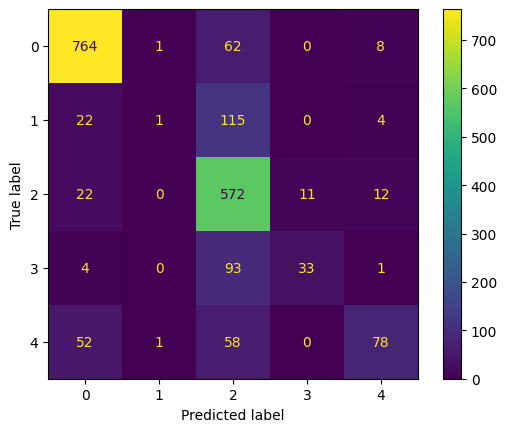

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_val)
y_pred = y_pred.argmax(axis=1)

cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

**ROC Curve**

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


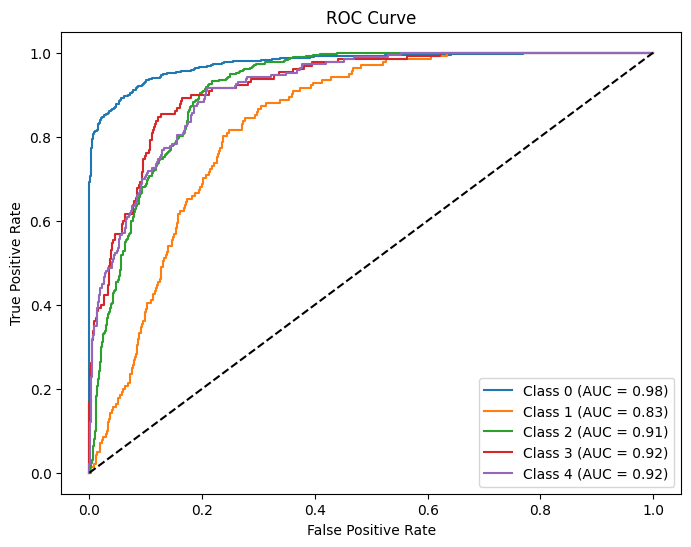

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np




y_pred_probs = model.predict(X_test)




n_classes = 5

y_test_bin = label_binarize(
    y_test,
    classes=[0,1,2,3,4]
)




plt.figure(figsize=(8,6))

for i in range(n_classes):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_pred_probs[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'Class {i} (AUC = {roc_auc:.2f})'
    )




plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.show()

**F1-Score**

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Macro F1:", f1_score(y_test, y_pred, average='macro'))
print("Weighted F1:", f1_score(y_test, y_pred, average='weighted'))

Macro F1: 0.1844601321052169
Weighted F1: 0.31990450218008104
